In [1]:
# import package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import random
import seaborn as sns
from sklearn import svm, decomposition
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from mplsoccer.pitch import Pitch
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc, roc_auc_score, f1_score, precision_score, \
recall_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from scipy.ndimage import gaussian_filter
import matplotlib.patheffects as path_effects
import eli5
from sklearn.pipeline import Pipeline

In [2]:
# import all datasets
en = pd.read_csv('shots_England.csv')
eu = pd.read_csv('shots_European_Championship.csv')
fr = pd.read_csv('shots_France.csv')
de = pd.read_csv('shots_Germany.csv')
it = pd.read_csv('shots_Italy.csv')
es = pd.read_csv('shots_Spain.csv')
wc = pd.read_csv('shots_World_Cup.csv')

In [3]:
# mark the game 
en['Competition'] = 'England'
eu['Competition'] = 'European_Championship'
fr['Competition'] = 'France'
de['Competition'] = 'Germany'
it['Competition'] = 'Italy'
es['Competition'] = 'Spain'
wc['Competition'] = 'World_Cup'

In [4]:
# combine all the dataframes
data = pd.concat([en,eu,fr,de,it,es,wc])
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45287 entries, 0 to 1504
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   period       45287 non-null  int64 
 1   time         45287 non-null  int64 
 2   x            45287 non-null  int64 
 3   y            45287 non-null  int64 
 4   freeKick     45287 non-null  int64 
 5   rightFoot    45287 non-null  int64 
 6   leftFoot     45287 non-null  int64 
 7   head         45287 non-null  int64 
 8   opportunity  45287 non-null  int64 
 9   goal         45287 non-null  int64 
 10  Competition  45287 non-null  object
dtypes: int64(10), object(1)
memory usage: 4.1+ MB


In [5]:
# check whether there are none values
data.isna().sum()

period         0
time           0
x              0
y              0
freeKick       0
rightFoot      0
leftFoot       0
head           0
opportunity    0
goal           0
Competition    0
dtype: int64

<AxesSubplot:>

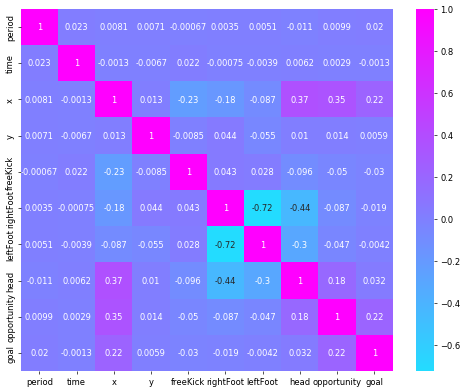

In [6]:
# plot correlation between variables, try to avoid color blindness
plt.figure(figsize=(10,8), dpi= 60)
sns.heatmap(data.corr(), xticklabels=data.corr().columns, yticklabels=data.corr().columns, cmap='cool', center=False, annot=True)

In [7]:
# re-define location variables to match the real size
data['x'] = data['x'] * 1.25
data['y'] = data['y'] * 0.85

In [8]:
data.head()

,period,time,x,y,freeKick,rightFoot,leftFoot,head,opportunity,goal,Competition
0,1,95,110.00,34.85,0,1,0,0,1,1,England
1,1,180,106.25,44.20,0,0,1,0,1,0,England
2,1,255,120.00,44.20,0,0,0,1,1,1,England
3,1,426,101.25,28.05,0,0,1,0,1,0,England
4,1,815,93.75,25.50,0,1,0,0,1,0,England


In [9]:
# visualize the location
post_x = 125
post_y1, post_y2 = (85/2-7.32/2, 85/2+7.32/2)

In [10]:
# get variables for plots
df = data[['x','y','goal']]
df = df[df['goal']==1]
def append(y1, y2):
    y = []
    for i in range(4629):
        x = random.uniform(y1, y2)
        y.append(x)
    new_df= df.assign(end_x = post_x, end_y = y)
    return new_df
df = append(post_y1, post_y2)

Text(0.5, 1.0, 'Scoring path')

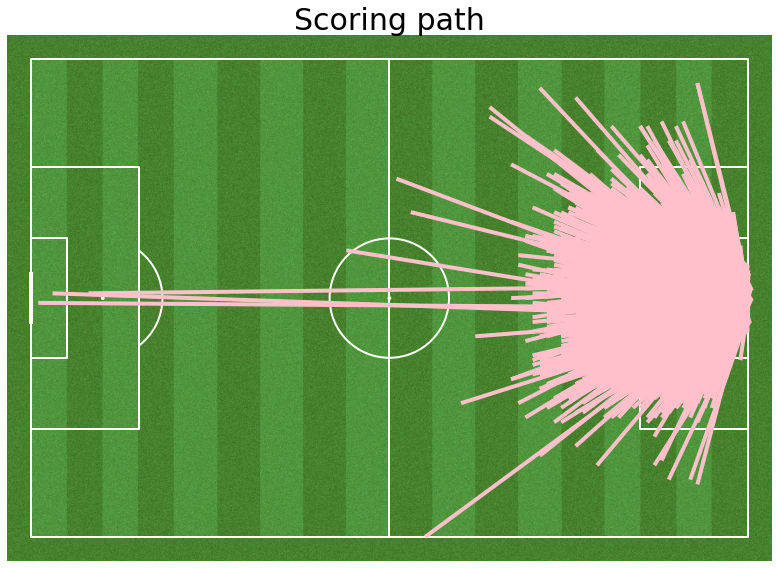

In [42]:
# Plot the scoring path
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white', stripe=True)
fig, ax = pitch.draw(figsize=(12,8))
pitch.arrows(df.x, df.y, df.end_x, df.end_y, headwidth=3, headlength=3, color='pink', ax=ax, label='Goal')
ax.set_title('Scoring path', fontsize=30)

Text(0.5, 1.0, 'Scoring probability')

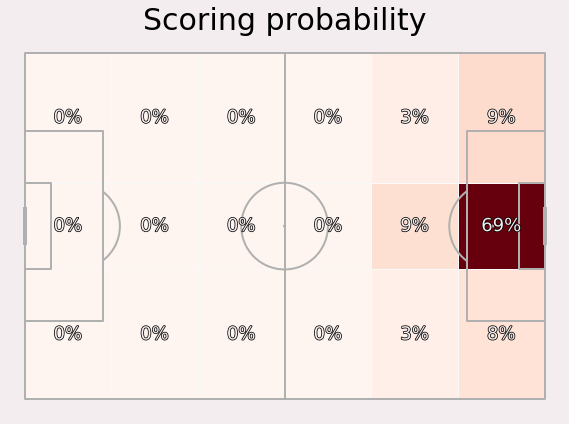

In [45]:
# heatmap, refer to https://mplsoccer.readthedocs.io/en/latest/gallery/pitch_plots/plot_heatmap.html
path_eff = [path_effects.Stroke(linewidth=1.5, foreground='black'),
            path_effects.Normal()]
pitch = Pitch(pitch_type='statsbomb', line_zorder=2, pitch_color='#f4edf0')
fig, ax = pitch.draw(figsize=(10, 6))
fig.set_facecolor('#f4edf0')
bin_x = np.linspace(pitch.dim.left, pitch.dim.right, num=7)
bin_y = np.sort(np.array([pitch.dim.bottom, pitch.dim.six_yard_bottom,
                          pitch.dim.six_yard_top, pitch.dim.top]))
bin_statistic = pitch.bin_statistic(df.x, df.y, statistic='count',
                                    bins=(bin_x, bin_y), normalize=True)
pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', edgecolor='#f9f9f9')
labels2 = pitch.label_heatmap(bin_statistic, color='#f4edf0', fontsize=18,
                              ax=ax, ha='center', va='center',
                              str_format='{:.0%}', path_effects=path_eff)
ax.set_title('Scoring probability', fontsize=30)

In [11]:
# calculate distance
data['distance_down'] = np.sqrt((post_x- data.x)**2+(data.y- post_y1)**2)
data['distance_up'] = np.sqrt((post_x- data.x)**2+(data.y- post_y2)**2)

In [12]:
# calculate angles
data['angle_up'] = np.arctan((data.y- post_y2).abs()/(post_x-data.x))
data['angle_down'] = np.arctan((data.y- post_y1).abs()/(post_x-data.x))
data['view_area'] = (data['angle_up']-data['angle_down']).abs()

In [13]:
# get necessary dummies for variables
data= pd.get_dummies(data, columns = ['period','Competition'],prefix = ['period','competition'], drop_first = True)

In [14]:
# features and labels
cols = data.columns.to_list()
features = ['freeKick', 'rightFoot', 'leftFoot', 'head', 'opportunity', 'distance_down', 'distance_up', 'view_area', 'competition_European_Championship', 'competition_France', 'competition_Germany', 'competition_Italy', 'competition_Spain', 'competition_World_Cup']
labels = ['goal']

In [15]:
# split data into train and validation set: 70:30
X_train, X_val, y_train, y_val = train_test_split(data[features], data[labels], test_size = 0.3, random_state =100) 
# balance the training data
smote = SMOTE(random_state=100)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

In [82]:
# pipe and parameters
logistic_Reg = LogisticRegression(solver = 'liblinear')
n_components = list(range(1,X_sm.shape[1]+1,1))
C = np.logspace(-4, 4, 50)
penalty = ['l1', 'l2']
pipe = Pipeline(steps=[('std_slc', StandardScaler()), ('pca', decomposition.PCA()), ('logistic_Reg', logistic_Reg)])
parameters = dict(pca__n_components=n_components,logistic_Reg__C=C,logistic_Reg__penalty=penalty)              

In [83]:
# fit grid, doesn't work with the solver
clf_GS = GridSearchCV(pipe, parameters)
clf_GS.fit(X_sm, y_sm)

GridSearchCV(estimator=Pipeline(steps=[('std_slc', StandardScaler()),
                                       ('pca', PCA()),
                                       ('logistic_Reg',
                                        LogisticRegression(solver='liblinear'))]),
             param_grid={'logistic_Reg__C': array([1.00000000e-04, 1.45634848e-04, 2.12095089e-04, 3.08884360e-04,
       4.49843267e-04, 6.55128557e-04, 9.54095476e-04, 1.38949549e-03,
       2.02358965e-03, 2.94705170e-03, 4.29193426e-03, 6.250551...
       1.67683294e+01, 2.44205309e+01, 3.55648031e+01, 5.17947468e+01,
       7.54312006e+01, 1.09854114e+02, 1.59985872e+02, 2.32995181e+02,
       3.39322177e+02, 4.94171336e+02, 7.19685673e+02, 1.04811313e+03,
       1.52641797e+03, 2.22299648e+03, 3.23745754e+03, 4.71486636e+03,
       6.86648845e+03, 1.00000000e+04]),
                         'logistic_Reg__penalty': ['l1', 'l2'],
                         'pca__n_components': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                

In [87]:
print('Best Penalty:', clf_GS.best_estimator_.get_params()['logistic_Reg__penalty'])
print('Best C:', clf_GS.best_estimator_.get_params()['logistic_Reg__C'])
print('Best Number Of Components:', clf_GS.best_estimator_.get_params()['pca__n_components']) 
print(); print(clf_GS.best_estimator_.get_params()['logistic_Reg'])



Best Penalty: l1
Best C: 0.019306977288832496
Best Number Of Components: 14

LogisticRegression(C=0.019306977288832496, penalty='l1', solver='liblinear')


In [88]:
# construct a logistic regression
lr = LogisticRegression(C=0.019306977288832496, penalty='l1', solver='liblinear')

In [89]:
# fit the model
lr.fit(X_sm, y_sm)

LogisticRegression(C=0.019306977288832496, penalty='l1', solver='liblinear')

In [90]:
# get predicted value and measurements for logistic regression
y_pred_lr = lr.predict(X_val)
print(classification_report(y_val, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.71      0.81     12179
           1       0.22      0.72      0.34      1408

    accuracy                           0.71     13587
   macro avg       0.59      0.71      0.58     13587
weighted avg       0.88      0.71      0.76     13587



AUC score on Testing: 0.7892121964782897


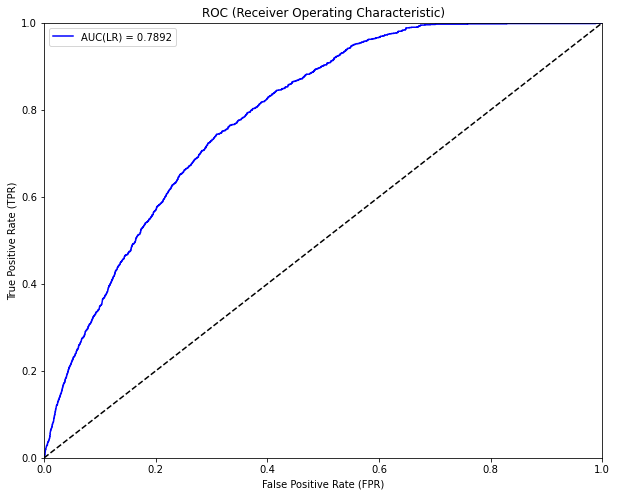

In [91]:
# AUC and ROC for logistic regression
y_pred_probs_lr = lr.predict_proba(X_val)
fpr, tpr, thresholds = roc_curve(y_val, y_pred_probs_lr[:,1])
roc_auc = auc(fpr, tpr)
print("AUC score on Testing: " + str(roc_auc))

fig, axs = plt.subplots(1,1, figsize=(10,8))

plt.title('ROC (Receiver Operating Characteristic)')
plt.plot(fpr, tpr, 'b', label='AUC(LR) = %0.4f'% roc_auc)
plt.legend(loc='best')
plt.plot([0,1],[0,1],color='black', linestyle='--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate (TPR)')
plt.xlabel('False Positive Rate (FPR)');

In [92]:
# explain weights
eli5.explain_weights(lr, feature_names=list(X_train.columns))

Weight?,Feature
+3.573,opportunity
+1.043,<BIAS>
+0.698,view_area
-0.036,distance_up
-0.056,distance_down
-1.049,competition_France
-1.118,competition_Italy
-1.128,competition_Spain
-1.174,competition_Germany
-1.796,rightFoot


In [16]:
# construct a svc with sigmoid
svc = svm.SVC(kernel = 'sigmoid', probability = True)

In [17]:
# fit with balanced data
svc.fit(X_sm, y_sm)

SVC(kernel='sigmoid', probability=True)

In [18]:
# get predicted value and measurements for SVM
y_pred_svm = svc.predict(X_val)
print(classification_report(y_val, y_pred_svm))

              precision    recall  f1-score   support

           0       0.93      0.63      0.76     12179
           1       0.16      0.62      0.26      1408

    accuracy                           0.63     13587
   macro avg       0.55      0.63      0.51     13587
weighted avg       0.86      0.63      0.70     13587



AUC score on Testing: 0.6821592996794034


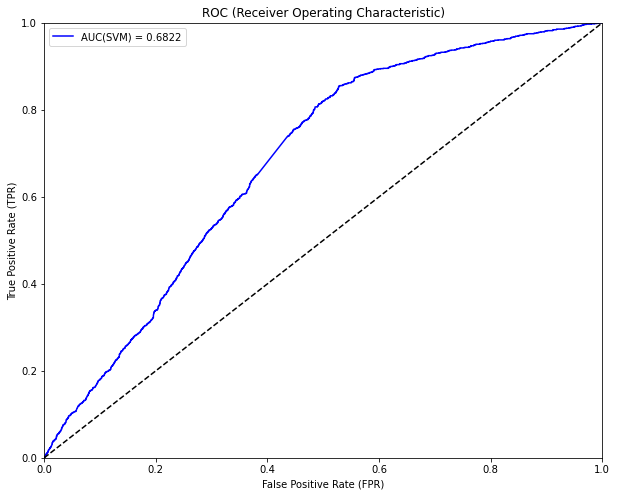

In [19]:
# AUC & ROC for SVM
y_pred_probs_svm = svc.predict_proba(X_val)
fpr, tpr, thresholds = roc_curve(y_val, y_pred_probs_svm[:,1])
roc_auc = auc(fpr, tpr)
print("AUC score on Testing: " + str(roc_auc))

fig, axs = plt.subplots(1,1, figsize=(10,8))

plt.title('ROC (Receiver Operating Characteristic)')
plt.plot(fpr, tpr, 'b', label='AUC(SVM) = %0.4f'% roc_auc)
plt.legend(loc='best')
plt.plot([0,1],[0,1],color='black', linestyle='--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate (TPR)')
plt.xlabel('False Positive Rate (FPR)');

In [97]:
# weights for svm
eli5.explain_weights(svm, feature_names=list(X_train.columns))

Weight?,Feature
+3.573,opportunity
+1.043,<BIAS>
+0.698,view_area
-0.036,distance_up
-0.056,distance_down
-1.049,competition_France
-1.118,competition_Italy
-1.128,competition_Spain
-1.174,competition_Germany
-1.796,rightFoot


In [20]:
# define Gradient boosting classifier params
def evaluate_model(params): 
    model = GradientBoostingClassifier(
                        learning_rate=params['learning_rate'],
                        min_samples_leaf=params['min_samples_leaf'],
                        max_depth = params['max_depth']
                        )

    model.fit(X_train, y_train)
    return {
        'learning_rate': params['learning_rate'],
        'min_samples_leaf': params['min_samples_leaf'],
        'max_depth': params['max_depth'],
        'train_ROCAUC': roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]),
        'val_ROCAUC': roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]),
        'recall': recall_score(y_val, model.predict(X_val)),
        'precision': precision_score(y_val, model.predict(X_val)),
        'f1_score': f1_score(y_val, model.predict(X_val)),
        'train_accuracy': model.score(X_train, y_train),
        'validation_accuracy': model.score(X_val, y_val)
    }

def objective(params):
    res = evaluate_model(params)
    
    res['loss'] = - res['val_ROCAUC'] 
    res['status'] = STATUS_OK 
    return res 

hyperparameter_space = {
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
        'min_samples_leaf': hp.choice('min_samples_leaf', range(15, 200)),
        'max_depth': hp.choice('max_depth', range(2, 20))
}

In [21]:
# find params
trials = Trials()
fmin(
    fn = objective,
    space=hyperparameter_space,
    algo=tpe.suggest,
    max_evals = 50,
    trials=trials
);

100%|████████| 50/50 [06:16<00:00,  7.53s/trial, best loss: -0.8146491095887853]


In [22]:
pd.DataFrame(trials.results).sort_values(by='f1_score', ascending=False).head(5)

,learning_rate,min_samples_leaf,max_depth,train_ROCAUC,val_ROCAUC,recall,precision,f1_score,train_accuracy,validation_accuracy,loss,status
22,0.187035,21,19,0.959095,0.781274,0.175426,0.430314,0.249243,0.927539,0.890484,-0.781274,ok
0,0.147659,35,13,0.916509,0.794892,0.144886,0.523077,0.226919,0.912555,0.897696,-0.794892,ok
19,0.069580,29,18,0.931420,0.791677,0.142045,0.531915,0.224215,0.913596,0.898138,-0.791677,ok
12,0.265600,123,13,0.893817,0.800206,0.139915,0.536785,0.221972,0.908486,0.898359,-0.800206,ok
3,0.295037,61,11,0.906041,0.797604,0.135653,0.530556,0.216063,0.910883,0.897991,-0.797604,ok


In [23]:
# construct gradient boosting classifier
model = GradientBoostingClassifier(
                        learning_rate=0.187035,
                        min_samples_leaf=21,
                        max_depth = 19)
model.fit(X_sm, y_sm)

GradientBoostingClassifier(learning_rate=0.187035, max_depth=19,
                           min_samples_leaf=21)

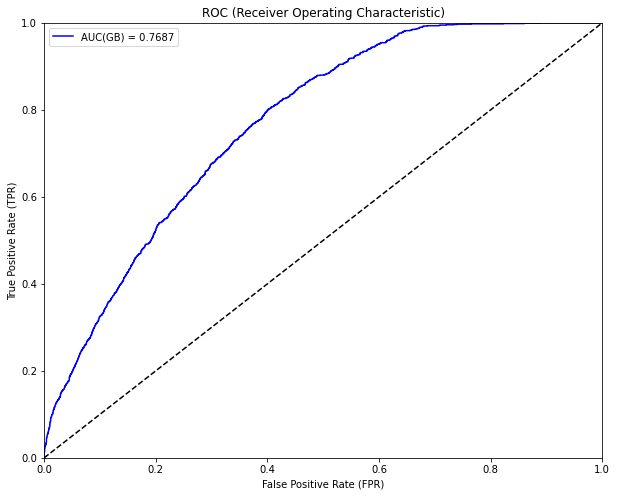

In [24]:
# get predicted value, AUC & ROC for gradient boosting classifier
y_pred_gb = model.predict(X_val)
y_pred_probs_gb = model.predict_proba(X_val)
fpr, tpr, thresholds = roc_curve(y_val, y_pred_probs_gb[:,1])
roc_auc = auc(fpr, tpr)

fig, axs = plt.subplots(1,1, figsize=(10,8))

plt.title('ROC (Receiver Operating Characteristic)')
plt.plot(fpr, tpr, 'b', label='AUC(GB) = %0.4f'% roc_auc)
plt.legend(loc='best')
plt.plot([0,1],[0,1],color='black', linestyle='--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate (TPR)')
plt.xlabel('False Positive Rate (FPR)');

In [25]:
# explain weights for gradient boosting classifier
eli5.explain_weights(model, feature_names=list(X_train.columns))

Weight,Feature
0.2598 ± 0.1816,distance_down
0.2338 ± 0.1395,opportunity
0.1979 ± 0.1950,distance_up
0.1560 ± 0.3208,view_area
0.0252 ± 0.0338,head
0.0232 ± 0.0369,rightFoot
0.0216 ± 0.0216,competition_France
0.0171 ± 0.0153,competition_Italy
0.0147 ± 0.0181,competition_Spain
0.0132 ± 0.0169,competition_Germany
